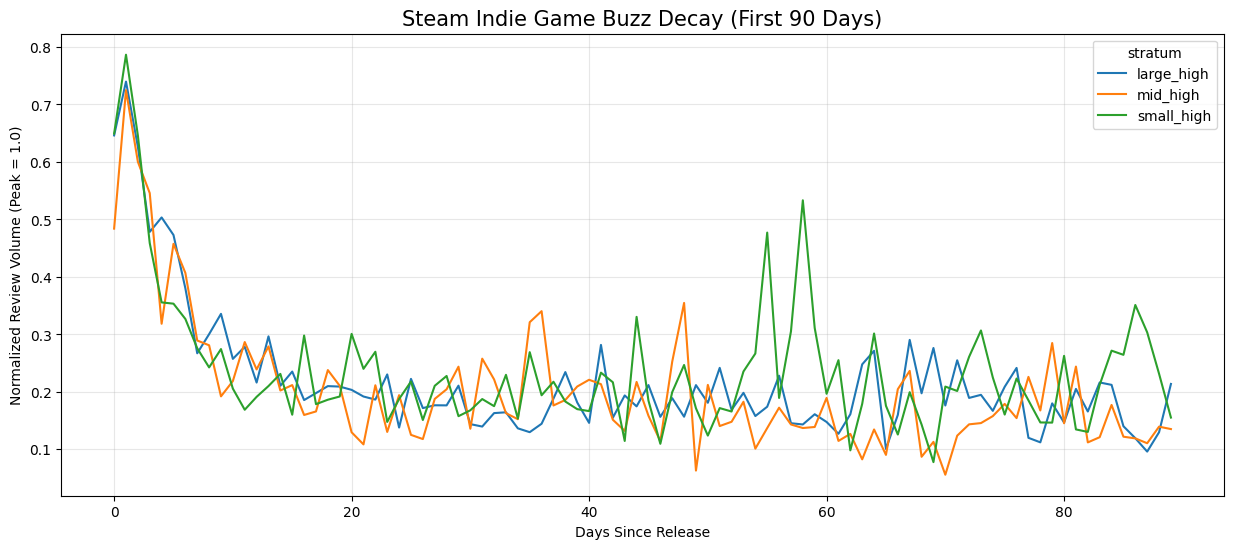


 체급별 평균 롱테일 지수 (Tail Ratio)
 (1.0에 가까울수록 초기 화제성이 후반까지 잘 유지됨)
stratum
small_high    0.721973
mid_high      0.621439
large_high    0.569800
Name: tail_ratio, dtype: float64


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 74개 정예 필터링 (유저님 로직 유지)
df_reviews = pd.read_csv('steam_indie_reviews.csv')
df_sample = pd.read_csv('steam_stratified_sample.csv')

df_reviews.columns = df_reviews.columns.str.strip()
df_sample.columns = df_sample.columns.str.strip()
df_reviews['appid'] = df_reviews['appid'].astype(str)
df_sample['appid'] = df_sample['appid'].astype(str)

# 74개 정예 게임 추출
target_strata = ['large_high', 'mid_high', 'small_high']
df_high = df_sample[df_sample['stratum'].isin(target_strata)].copy()

# 2. 날짜 계산 및 초기 90일 필터링
df_high['release_date_dt'] = pd.to_datetime(df_high['release_date'])
df_reviews['review_date'] = pd.to_datetime(df_reviews['timestamp_created'], unit='s')

df_merged = pd.merge(df_reviews, df_high[['appid', 'release_date_dt', 'stratum']], on='appid')
df_merged['days_since_release'] = (df_merged['review_date'] - df_merged['release_date_dt']).dt.days
df_90d = df_merged[(df_merged['days_since_release'] >= 0) & (df_merged['days_since_release'] <= 90)].copy()

# 3. 일별 리뷰 발생량 집계
daily_reviews = df_90d.groupby(['stratum', 'appid', 'days_since_release']).size().reset_index(name='daily_count')

# 4. 화제성 정규화 (transform을 사용하여 KeyError 원천 차단)
# 각 게임(appid)별 최대 리뷰 발생량을 구해서 나눠줍니다.
daily_reviews['norm_count'] = daily_reviews['daily_count'] / daily_reviews.groupby('appid')['daily_count'].transform('max')

# 5. 시각화: 체급별 평균 화제성 감쇄 곡선
plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_reviews, x='days_since_release', y='norm_count', hue='stratum', errorbar=None)
plt.title('Steam Indie Game Buzz Decay (First 90 Days)', fontsize=15)
plt.xlabel('Days Since Release')
plt.ylabel('Normalized Review Volume (Peak = 1.0)')
plt.grid(True, alpha=0.3)
plt.show()

# 6. 롱테일 지수(Tail Ratio) 계산
# 0-30일 대비 31-90일의 리뷰 비중이 얼마나 되는지 측정
def calculate_tail_ratio(group):
    early = group[group['days_since_release'] <= 30]['daily_count'].sum()
    late = group[group['days_since_release'] > 30]['daily_count'].sum()
    return late / early if early > 0 else 0

# 결과를 깔끔하게 정리
summary_tail = daily_reviews.groupby(['stratum', 'appid']).apply(calculate_tail_ratio).reset_index(name='tail_ratio')

print("\n" + "="*60)
print(" 체급별 평균 롱테일 지수 (Tail Ratio)")
print(" (1.0에 가까울수록 초기 화제성이 후반까지 잘 유지됨)")
print("="*60)
# 전체 평균 출력
report = summary_tail.groupby('stratum')['tail_ratio'].mean().sort_values(ascending=False)
print(report)
print("="*60)